Cloning into 'RUET_CSE_LAB'...
remote: Enumerating objects: 424, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 424 (delta 1), reused 13 (delta 1), pack-reused 403 (from 1)
Receiving objects: 100% (424/424), 93.20 KiB | 745.00 KiB/s, done.
Resolving deltas: 100% (3/3), done.
remote: Enumerating objects: 2, done.
remote: Counting objects: 100% (2/2), done.
remote: Total 2 (delta 0), reused 2 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (2/2), 1.19 KiB | 609.00 KiB/s, done.
/content/RUET_CSE_LAB/RUET_CSE_LAB/RUET_CSE_LAB
remote: Enumerating objects: 13, done.
remote: Total 13 (delta 0), reused 0 (delta 0), pack-reused 13 (from 1)
Receiving objects: 100% (13/13), 1.07 MiB | 2.94 MiB/s, done.


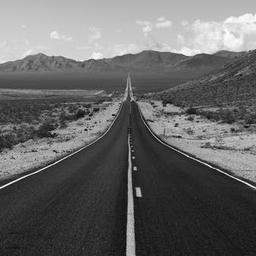

(256, 256) uint8


In [ ]:
# Bilinear interpolation

import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import numpy as np

!git clone --filter=blob:none --sparse https://github.com/asadaladil/RUET_CSE_LAB.git
%cd RUET_CSE_LAB
!git sparse-checkout set "4106-Digital Image Processing/Images_for_DIP"

path="/content/RUET_CSE_LAB/4106-Digital Image Processing/Images_for_DIP/road.bmp"

image=cv2.imread(path)
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
cv2_imshow(image_gray)
print(image_gray.shape,image_gray.dtype)

def Bilinear_Interpolation(image,H_out,W_out):
  H_in=image_gray.shape[0]
  W_in=image_gray.shape[1]
  resize_image=np.zeros((H_out,W_out))

  for i in range(H_out):
    for j in range(W_out):

      # step-01:
      x=(j+0.5)*(W_in/W_out)-0.5
      y=(i+0.5)*(H_in/H_out)-0.5

      # step-02:
      x0=int(np.floor(x))
      y0=int(np.floor(y))

      x1=min(x0+1,W_in-1)
      y1=min(y0+1,H_in-1)

      # step-03:
      x0=max(x0,0)
      y0=max(y0,0)

      #step-04:
      dx=x-x0
      dy=y-y0

      #step-05:
      A=image_gray[y0, x0]
      B=image_gray[y0, x1]
      C=image_gray[y1, x0]
      D=image_gray[y1, x1]

      #step-06:
      Top=A*(1-dx)+(B*dx)
      Bottom=C*(1-dx)+(D*dx)
      value=Top*(1-dy)+Bottom*dy
      resize_image[i,j]=value
  return resize_image

In [ ]:
resize_image=Bilinear_Interpolation(image_gray,500,500)

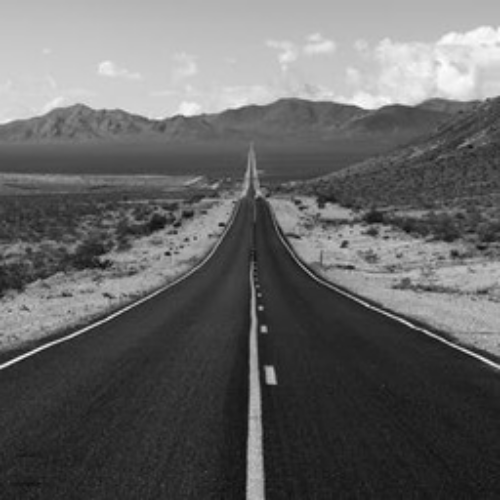

(500, 500)
float64


In [ ]:
cv2_imshow(resize_image)
print(resize_image.shape)
print(resize_image.dtype)

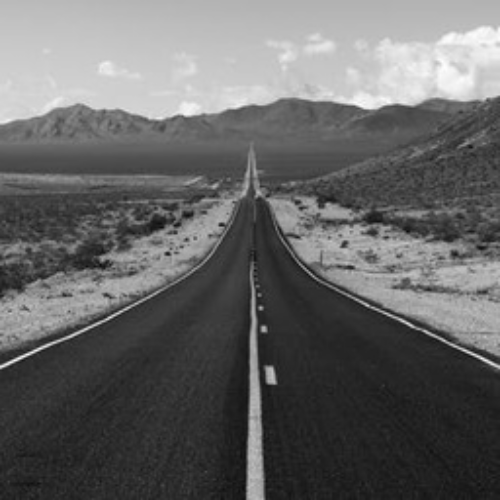

(500, 500)
uint8


In [ ]:
# using built in function:

resize_image_func=cv2.resize(image_gray,(500,500),interpolation=cv2.INTER_LINEAR)
cv2_imshow(resize_image_func)
print(resize_image_func.shape)
print(resize_image_func.dtype)

# Comparison:

diff=abs(resize_image.astype(np.int16)-resize_image_func.astype(np.int16))
cv2_imshow(diff)

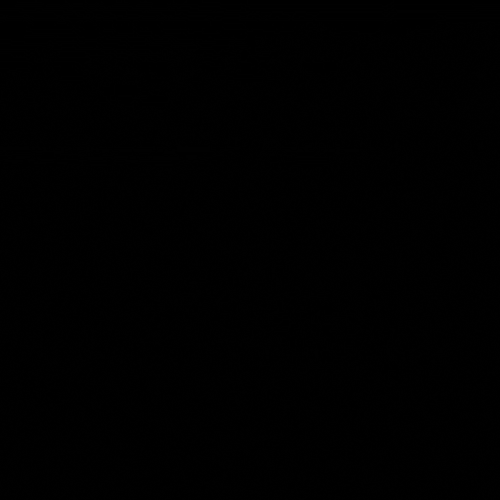

In [ ]:
# # Comparison:

# diff=abs(resize_image.astype(np.int16)-resize_image_func.astype(np.int16))
# cv2_imshow(diff)

In [ ]:
# Nearest Neighbor interpolation

def Nearest_Neighbor_Interpolation(image,height,width):
  H_in=image.shape[0]
  W_in=image.shape[1]
  resize_image=np.zeros((height,width))
  if height%H_in!=0 or width%W_in!=0:
    return resize_image

  factor1=height/H_in
  factor2=width/W_in
  for i in range(height):
    for j in range(width):
      resize_image[i,j]=image[int(i/factor1),int(j/factor2)]

  return resize_image


image=[
      [1,4,7],
      [2,5,8],
      [3,6,9]
  ]
image=np.array(image)
print(Nearest_Neighbor_Interpolation(image,9,9))

[[1. 1. 1. 4. 4. 4. 7. 7. 7.]
 [1. 1. 1. 4. 4. 4. 7. 7. 7.]
 [1. 1. 1. 4. 4. 4. 7. 7. 7.]
 [2. 2. 2. 5. 5. 5. 8. 8. 8.]
 [2. 2. 2. 5. 5. 5. 8. 8. 8.]
 [2. 2. 2. 5. 5. 5. 8. 8. 8.]
 [3. 3. 3. 6. 6. 6. 9. 9. 9.]
 [3. 3. 3. 6. 6. 6. 9. 9. 9.]
 [3. 3. 3. 6. 6. 6. 9. 9. 9.]]


In [ ]:
def four_adjacency(image,start,end,V):
  H_in=image.shape[0]
  W_in=image.shape[1]

  if start not in V or end not in V:
    return -1

  path={'P1':[start],
        'P2':[start],
        'P3':[start],
        'P4':[start],
        }
  start=list(start)






In [ ]:
# Experiment1: Reading and Displaying image

#import the libraries
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import cv2
#reading the image
image=cv2.imread('rgb.png')
cv2_imshow(image)
plt.imshow(image)
#save the image
cv2.imwrite('testing_save.png',image)


# Experiment 2: Changing the color spaces

#converting the image into grayscale
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
#display the image
cv2_imshow(image_gray)
plt.imshow(image_gray)


#converting the image in HSV color space
image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
#display the image
cv2_imshow(image_hsv)
plt.imshow(image_hsv)
#converting the image in HSV color space
image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
#display the image
cv2_imshow(image_hsv)
plt.imshow(image_hsv)


#converting the image in RGB color space
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#display the image
cv2_imshow(image_rgb)
plt.imshow(image_rgb)


# Experiment 3: Accessing Image Property

import numpy as np
import matplotlib.pyplot as plt
import cv2
#reading the image
image = cv2.imread('/content/rgb.png')
#Displaying image properties
print('Image shape:', image.shape)
print('Total number of pixels:', image.size)
print('Dimension:', image.ndim)
print (type(image))
print(image)
print(image[0][0])

# another way to accessing image properties

height = image.shape[0]
width = image.shape[1]
num_channels = image.shape[2]
print('The height of the input image is : ', height)
print('The width of the input image is : ', width)
print('The Number of Channels in the input image are : ', num_channels)

# Experiment 4: Splitting & Merging Image Channels

b, g, r = cv2.split(image)
rgb_image = cv2.merge((r, g, b))
num_red_pixels = cv2.countNonZero(r)
num_green_pixels = cv2.countNonZero(g)
num_blue_pixels = cv2.countNonZero(b)
# Display the total number of pixels for each color channel
print('Total number of red pixels:', num_red_pixels)
print('Total number of green pixels:', num_green_pixels)
print('Total number of blue pixels:', num_blue_pixels)

#Experiment 5 -- Name of the Experiment: Separating Image Channels and Displaying them Individually

#import the libraries
import numpy as np
import matplotlib.pyplot as plt
import cv2
#reading the image
image = cv2.imread('/content/rgb.jpg')
#Create subplot of one row and three columns within 10 inches widhth and 5 inches height figure
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
# Display the red channel image in the first subplot
ax[0].imshow(r)

ax[0].set_title('Red Channel')
# Display the green channel image in the second subplot
ax[1].imshow(g)
ax[1].set_title('Green Channel')
# Display the blue channel image in the third subplot
ax[2].imshow(b)
ax[2].set_title('Blue Channel')

#Another ways to seperate the image channels and display
import cv2
import matplotlib.pyplot as plt
# Load an image
image = cv2.imread('/content/rgb.png')
# Extract the channel pixel array
r = image[:,:,2]
g = image[:,:,1]
b = image[:,:,0]
print(r)

# Experiment 6
# Name of the Experiment: Converting Image from One Format to Another
# Introduction/Description

import os
import cv2
# Set the directory path containing JPEG images
input_dir = '/content/drive/MyDrive/Jpg Images'
# Create a directory for storing the output PNG images
output_dir = '/content/drive/MyDrive/PNG Images'
if not os.path.exists(output_dir):
  os.makedirs(output_dir)
  # Loop through all the JPEG images in the input directory
  for filename in os.listdir(input_dir):
    if filename.endswith('.jpg') or filename.endswith('.jpeg'):
      # Load the image
      img_path = os.path.join(input_dir, filename)
      img = cv2.imread(img_path)
      # Convert the image to PNG format
      png_filename = os.path.splitext(filename)[0] + '.png'
      png_path = os.path.join(output_dir, png_filename)
      cv2.imwrite(png_path, img)


# Experiment 7
# Name of the Experiment: Image Resize and Rotation Code
import cv2
import matplotlib.pyplot as plt
# Load an image
image = cv2.imread('/content/rgb.png')
image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
#rotation of an image
rotated_image = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)
#resizing of an image
resized_img = cv2.resize(image, (512,256), interpolation = cv2.INTER_LINEAR)
plt.figure()
plt.imshow(rotated_image)
plt.show()
cv2_imshow(resized_img)
print(resized_img.shape)



In [ ]:
# lab-03
# Exp-01: Performing Gray Level Transformations for Image Enhancement

# Importing the Libraries & Loading the Image
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import numpy as np
import warnings
image = cv2.imread('/content/Low Contrast.PNG', cv2.IMREAD_GRAYSCALE)
cv2_imshow(image)
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.title('Original Image')

# Exp-02: Image Negative

# Negative Transformation Formula
negative = 255 - image
# Displaying Results
fig = plt.figure(figsize=(8, 8))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax1.imshow(image, cmap='gray', vmin=0, vmax=255)
ax1.title.set_text('Original Image')
ax2.imshow(negative, cmap='gray', vmin=0, vmax=255)
ax2.title.set_text('Negative Image')


negative_image = np.zeros_like(image)
for i in range(image.shape[0]):
  for j in range(image.shape[1]):
    new_pixel = 255 - image[i,j]
    negative_image[i,j] = new_pixel
# Displaying Results
fig = plt.figure(figsize=(8, 8))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax1.imshow(image, cmap='gray', vmin=0, vmax=255)
ax1.title.set_text('Original Image')
ax2.imshow(negative_image, cmap='gray', vmin=0, vmax=255)
ax2.title.set_text('Negative Image')
print(image)
print(negative_image)

# Experiment 3:Log Transformation

# Log Transformation
c = round(255 / np.log(1 + np.max(image)))
log_image = c * (np.log(1+image))
log_image = np.array(log_image, dtype = np.uint8)

#Displaying Results
fig = plt.figure(figsize=(8, 8))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax1.imshow(image, cmap='gray', vmin=0, vmax=255)
ax1.title.set_text('Original Image')
ax2.imshow(log_image, cmap='gray', vmin=0, vmax=255)
ax2.title.set_text(f'Log Transformed Image (c={c})')

# Log Transformation Using For Loop
c = 255 / np.log(1 + np.max(image))
log_image = np.zeros_like(image)
for i in range(image.shape[0]):
  for j in range(image.shape[1]):
    new_pixel = c * np.log(1 + image[i,j])
    log_image[i,j] = new_pixel

#Displaying Results
fig = plt.figure(figsize=(8, 8))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax1.imshow(image, cmap='gray', vmin=0, vmax=255)
ax1.title.set_text('Original Image')
ax2.imshow(log_image, cmap='gray', vmin=0, vmax=255)
ax2.title.set_text(f'Log Transformed Image (c={c})')
plt.show()
print(image)
print(log_image)

# Exp-04: Gamma Correction:

gamma_image = np.zeros_like(image)
gamma = 1.5
c = 255 / (255 ** gamma)

# Apply gamma correction using a for loop
for i in range(image.shape[0]):
  for j in range(image.shape[1]):
    pixel_value = image[i,j]
    corrected_value = c * (pixel_value ** gamma)
    gamma_image[i,j] = corrected_value

print(image)
print(gamma_image)
cv2_imshow(gamma_image)

#Exp-05: Contrast Stretching

# Importing the Libraries & Loading the Image
import cv2
import matplotlib.pyplot as plt
import numpy as np
import warnings
image = cv2.imread('/content/road.bmp', cv2.IMREAD_GRAYSCALE)
thresh_value = 128

# Create empty binary image
binary = np.zeros_like(image)
# Loop over each pixel in the image
for i in range(image.shape[0]):
  for j in range(image.shape[1]):
    # Apply thresholding
    if image[i,j] >= thresh_value:
      binary[i,j] = 255
    else:
      binary[i,j] = 0

# Displaying Results
fig = plt.figure(figsize=(8,8))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax1.imshow(image, cmap='gray', vmin=0, vmax=255)
ax1.title.set_text('Original Image')
ax2.imshow(binary, cmap='gray', vmin=0, vmax

$0=255)
ax2.title.set_text('Thresholded Binary Image')
plt.show()

# Min-Max Contrast Stretching
image = cv2.imread('/content/Low Contrast.PNG', cv2.IMREAD_GRAYSCALE)
r1, r2 = image.min(), image.max()
s1, s2 = 0, 255
# Apply the linear transformation using a for loop
output_image = np.zeros_like(image)
for i in range(image.shape[0]):
  for j in range(image.shape[1]):
    output_image[i,j] = (image[i,j] - r1) * ((s2 - s1) / (r2 - r1)) + s1 # Displaying Results
fig = plt.figure(figsize=(8,8))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax1.imshow(image, cmap='gray', vmin=0, vmax=255)
ax1.title.set_text('Original Image')
ax2.imshow(output_image, cmap='gray', vmin=0, vmax=255)
ax2.title.set_text('Contrast Stretched Image')
plt.show()

# Exp-06: Intensity Level Slicing

image = cv2.imread('/content/Dark.PNG', cv2.IMREAD_GRAYSCALE)
# Parameters
minimum_range = 64
maximum_range = 128
output_image = np.zeros_like(image)
for i in range(image.shape[0]):
  for j in range(image.shape[1]):
    if image[i,j] > minimum_range and image[i,j] < maximum_range:
      output_image[i,j] = 255
    else:
      output_image[i,j] = 0 # image[i,j] for second case
# Displaying Results
fig = plt.figure(figsize=(8,8))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax1.imshow(image, cmap='gray', vmin=0, vmax=255)
ax1.title.set_text('Original Image')
ax2.imshow(output_image, cmap='gray', vmin=0, vmax=255)
ax2.title.set_text(f'Intensity Level Sliced Image\nMin:{minimum_range}, Max:{maximum_range}')
plt.show()



In [ ]:
# lab-04
# !wget https://raw.githubusercontent.com/asadaladil/RUET_CSE_LAB/refs/heads/main/4106-Digital%20Image%20Processing/Images_for_DIP/road.bmp
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import numpy as np
import warnings

# Experiment 1
# Name of the Experiment: Identity Kernel Using Library Function

#Identity Kernel Filter
kernel1 = np.array([[0, 0, 0],
                    [0, 1, 0],
                    [0, 0, 0]])
identity = cv2.filter2D(src=image, ddepth=-1, kernel=kernel1)
fig = plt.figure(figsize=(8,8))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.imshow(image, cmap='gray', vmin=0, vmax=255)
ax1.title.set_text('Original Image')
ax2.imshow(identity, cmap='gray', vmin=0, vmax=255)
ax2.title.set_text('Result of Identity Kernel')

#Identity Kernel Filter
kernel = np.array([[0, 0, 0],
                  [0, 1, 0],
                  [0, 0, 0]])
padded_image = cv2.copyMakeBorder(image, 1, 1, 1, 1, cv2.BORDER_CONSTANT, value=0)

# Create output image
output_image = np.zeros_like(image)

# Apply the filter using for loops
for i in range(1, padded_image.shape[0]-1):
  for j in range(1, padded_image.shape[1]-1):
    # Compute the convolution using the Laplacian kernel
    convolution = np.sum(kernel * padded_image[i-1:i+2, j-1:j+2])
    # Set the corresponding pixel in the output image to the convolution value
    output_image[i-1, j-1] = convolution

#Display Results
fig = plt.figure(figsize=(8,8))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.imshow(image, cmap='gray', vmin=0, vmax=255)
ax1.title.set_text('Original Image')
ax2.imshow(output_image, cmap='gray', vmin=0, vmax=255)
ax2.title.set_text('Result of Identity Kernel')

# Experiment 2
# Name of the Experiment: Smoothing Spatial Filtering

# Image Blurring using a Custom Kernel
kernel1 = np.array([[1, 1, 1],
                    [1, 1, 1],
                    [1, 1, 1]])
kernel1=kernel1/9
blurr = cv2.filter2D(src=image, ddepth=-1, kernel=kernel1)
fig = plt.figure(figsize=(8,8))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.imshow(image, cmap='gray', vmin=0, vmax=255)
ax1.title.set_text('Original Image')
ax2.imshow(blurr, cmap='gray', vmin=0, vmax=255)
ax2.title.set_text('Result of Blurring Kernel')

# Standard Average Filtering Without Using Libray Function

#Identity Kernel Filter
kernel = np.ones((3, 3), dtype=np.float32)/9
padded_image = cv2.copyMakeBorder(image, 1, 1, 1, 1, cv2.BORDER_CONSTANT, value=0)

# Create output image
output_image = np.zeros_like(image)
# Apply the filter using for loops
for i in range(1, padded_image.shape[0]-1):
  for j in range(1, padded_image.shape[1]-1):
    # Compute the convolution using the Laplacian kernel
    convolution = np.sum(kernel * padded_image[i-1:i+2, j-1:j+2])
    # Set the corresponding pixel in the output image to the convolution value
    output_image[i-1, j-1] = convolution

#Display Results
fig = plt.figure(figsize=(8,8))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.imshow(image, cmap='gray', vmin=0, vmax=255)
ax1.title.set_text('Original Image')
ax2.imshow(output_image, cmap='gray', vmin=0, vmax=255)
ax2.title.set_text('Result of Standard Average Filtering Kernel')

# Maximum Filetering Using Library Function

kernel = np.ones((3,3),np.uint8)
# Perform maximum filtering convolution using dilation
max_filtered = cv2.dilate(image, kernel)
fig = plt.figure(figsize=(8,8))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.imshow(image, cmap='gray', vmin=0, vmax=255)
ax1.title.set_text('Original Image')
ax2.imshow(max_filtered, cmap='gray', vmin=0, vmax=255)
ax2.title.set_text('Result of Maximum Filtering')

# Maximum Filetering Without Using Library Function

# Pad the image using cv2.copyMakeBorder
padded_image = cv2.copyMakeBorder(image, 1, 1, 1, 1, cv2.BORDER_CONSTANT, value=0)
# Create output image
output_image = np.zeros_like(image)
# Apply the filter using for loops
for i in range(1, padded_image.shape[0]-1):
  for j in range(1, padded_image.shape[1]-1):
    # Extract the 3x3 neighborhood around the current pixel
    neighborhood = padded_image[i-1:i+2, j-1:j+2]
    # Compute the maximum value in the neighborhood
    maximum = np.max(neighborhood)
# Set the corresponding pixel in the output image to the maximum value
    output_image[i-1, j-1] = maximum

#Display Results
fig = plt.figure(figsize=(8,8))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.imshow(image, cmap='gray', vmin=0, vmax=255)
ax1.title.set_text('Original Image')
ax2.imshow(output_image, cmap='gray', vmin=0, vmax=255)
ax2.title.set_text('Result of Maximum Filtering Kernel')

# Minimum Filtering Using Library Function
kernel = np.ones((3,3),np.uint8)
# Perform maximum filtering convolution using dilation
min_filtered = cv2.erode(image, kernel)
fig = plt.figure(figsize=(8,8))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.imshow(image, cmap='gray', vmin=0, vmax=255)
ax1.title.set_text('Original Image')

ax2.imshow(min_filtered, cmap='gray', vmin=0, vmax=255)
ax2.title.set_text('Result of Minimum Filtering')

# Minimum Filtering Without Using Library Function

# Pad the image using cv2.copyMakeBorder
padded_image = cv2.copyMakeBorder(image, 1, 1, 1, 1, cv2.BORDER_CONSTANT, value=0)

# Create output image
output_image = np.zeros_like(image)

# Apply the filter using for loops
for i in range(1, padded_image.shape[0]-1):
  for j in range(1, padded_image.shape[1]-1):
    # Extract the 3x3 neighborhood around the current pixel
    neighborhood = padded_image[i-1:i+2, j-1:j+2]
    # Compute the maximum value in the neighborhood
    minimum = np.min(neighborhood)
    # Set the corresponding pixel in the output image to the maximum value
    output_image[i-1, j-1] = minimum


#Display Results
fig = plt.figure(figsize=(8,8))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.imshow(image, cmap='gray', vmin=0, vmax=255)
ax1.title.set_text('Original Image')
ax2.imshow(output_image, cmap='gray', vmin=0, vmax=255)
ax2.title.set_text('Result of Minimum Filtering Kernel')

# Perform Median blurring using cv2.filter2D
median_filtered = cv2.medianBlur(image, 3)
fig = plt.figure(figsize=(8,8))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.imshow(image, cmap='gray', vmin=0, vmax=255)
ax1.title.set_text('Original Image')
ax2.imshow(median_filtered, cmap='gray', vmin=0, vmax=255)
ax2.title.set_text('Result of Median Filtering')

# Median Filtering Without Using a Library Function

padded_image = cv2.copyMakeBorder(image, 1, 1, 1, 1,
cv2.BORDER_CONSTANT, value=255)
# Create output image
output_image = np.zeros_like(image)

# Apply the filter using for loops
for i in range(1, padded_image.shape[0]-1):
  for j in range(1, padded_image.shape[1]-1):
    # Extract the 3x3 neighborhood around the current pixel
    neighborhood = padded_image[i-1:i+2, j-1:j+2]
    # Compute the median value in the neighborhood
    median = np.median(neighborhood)
    # Set the corresponding pixel in the output image to the median
    output_image[i-1, j-1] = median

#Display Results
fig = plt.figure(figsize=(8,8))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.imshow(image, cmap='gray', vmin=0, vmax=255)
ax1.title.set_text('Original Image')
ax2.imshow(output_image, cmap='gray', vmin=0, vmax=255)
ax2.title.set_text('Result of Median Filtering Kernel')

# Weighted Averaging Filter Using Library Function
kernel = np.array([[1, 2, 1],
[2, 4, 2],
[1, 2, 1]]) / 16.0
weighted_filter = cv2.filter2D(image, -1, kernel)
fig = plt.figure(figsize=(8,8))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.imshow(image, cmap='gray', vmin=0, vmax=255)
ax1.title.set_text('Original Image')
ax2.imshow(weighted_filter, cmap='gray', vmin=0, vmax=255)
ax2.title.set_text('Result of Weighted Averaging Filtering')

# Weighted Averaging Filter Without Using Library Function
# Define filter kernel
kernel = np.array([[1, 2, 1],
                    [2, 4, 2],
                    [1, 2, 1]])
# Normalize kernel
kernel = kernel / np.sum(kernel) # Pad image
padded_image = cv2.copyMakeBorder(image, 1, 1, 1, 1, cv2.BORDER_CONSTANT, value=0)
# Create output image
output = np.zeros_like(image)
# Apply filter
for i in range(1, padded_image.shape[0] - 1):
  for j in range(1, padded_image.shape[1] - 1):
  # Compute the convolution using the Laplacian kernel
    convolution = np.sum(kernel * padded_image[i-1:i+2, j-1:j+2])
  # Set the corresponding pixel in the output image to the convolution value
    output_image[i-1, j-1] = convolution

#Display Results
fig = plt.figure(figsize=(8,8))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.imshow(image, cmap='gray', vmin=0, vmax=255)
ax1.title.set_text('Original Image')
ax2.imshow(output_image, cmap='gray', vmin=0, vmax=255)
ax2.title.set_text('Result of weighted Average Filtering Kernel')

gaussian_filter = cv2.GaussianBlur(image, (3,3), 0)
fig = plt.figure(figsize=(8,8))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.imshow(image, cmap='gray', vmin=0, vmax=255)
ax1.title.set_text('Original Image')
ax2.imshow(gaussian_filter, cmap='gray', vmin=0, vmax=255)
ax2.title.set_text('Gaussian Smoothing Filter')

# Experiment 3
# Name of the Experiment: Sharpening Spatial Filtering

# Laplacian Filtering Using Library Function
# Importing the Libraries & Loading the Image

kernel = np.array([[0, 1, 0],
[1,-4, 1], [0, 1, 0]])
laplacian = cv2.filter2D(image, -1, kernel)
fig = plt.figure(figsize=(8,8))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.imshow(image, cmap='gray', vmin=0, vmax=255)
ax1.title.set_text('Original Image')
ax2.imshow(laplacian, cmap='gray', vmin=0, vmax=255)
ax2.title.set_text('Laplacian Filter')

# Unsharp Masking and High Boost Filtering

# Gaussian Blur
gaussian_blur = cv2.GaussianBlur(image, (7,7), 0)
#Mask
mask = cv2.subtract(image, gaussian_blur)
k = 1
output_image = cv2.addWeighted(image, 1 + k, mask, -k, 0)
# Displaying Results
fig = plt.figure(figsize=(8,8))
ax1 = fig.add_subplot(121)
ax5 = fig.add_subplot(122)
ax1.imshow(image, cmap='gray', vmin=0, vmax=255)
ax1.title.set_text('Original Image')
ax5.imshow(output_image, cmap='gray', vmin=0, vmax=255)
ax5.title.set_text('Output of Unsharp Masking')

# High boost Filtering

# HighBoost Filtering
kernel = np.array([[-1, -1, -1],
[-1, 9, -1], [-1, -1, -1]])
highboost = cv2.filter2D(image, -1, kernel) # Displaying Results
fig = plt.figure(figsize=(8,8))
ax1 = fig.add_subplot(121)
ax5 = fig.add_subplot(122)
ax1.imshow(image, cmap='gray', vmin=0, vmax=255)
ax1.title.set_text('Original Image')
ax5.imshow(output_image, cmap='gray', vmin=0, vmax=255)
ax5.title.set_text('HighBoost Filtering')

# Sobel Operator
#Horizontal Edge Detection
sobel_h = np.array([[-1, -2, -1],
[0, 0, 0], [1, 2, 1]])

# Apply kernel to image using cv2.filter2D
horizontal_edges = cv2.filter2D(image, -1, sobel_h).astype(np.float32) #Vertical Edge Detection
sobel_v = np.array([[-1, 0, 1],
[-2, 0, 2], [-1, 0, 1]])
# Apply kernel to image using cv2.filter2D
vertical_edges = cv2.filter2D(image, -1, sobel_v).astype(np.float32)
#Both in Vertical and Horizontal Direction
sobel = cv2.magnitude(vertical_edges, horizontal_edges)
fig = plt.figure(figsize=(16,12))
ax1 = fig.add_subplot(141)
ax2 = fig.add_subplot(142)
ax3 = fig.add_subplot(143)
ax4 = fig.add_subplot(144)
ax1.imshow(image, cmap='gray', vmin=0, vmax=255)
ax1.title.set_text('Original Image')
ax2.imshow(horizontal_edges, cmap='gray', vmin=0, vmax=255)
ax2.title.set_text('Edges in Horizontal Direction')
ax3.imshow(vertical_edges, cmap='gray', vmin=0, vmax=255)
ax3.title.set_text('Edges in Vertical Direction')
ax4.imshow(sobel, cmap='gray', vmin=0, vmax=255)
ax4.title.set_text('Sobel Filtering')


In [ ]:
Q1. What is the output of print(image_gray.shape) for a 480×640 BGR image?

Q2. What does this code do?

b, g, r = cv2.split(image)
rgb_image = cv2.merge((r, g, b))

Answer of Q2:OpenCV loads images in BGR format while Matplotlib expects RGB Format


Q3. Explain what this code does and why it's useful.
height = image.shape[0]
width = image.shape[1]
num_channels = image.shape[2]
Answer:This code gives:image.shape[0] = Height (number of rows) image.shape[1] =Width (number of columns) image.shape[2] = Number of color channels

Q4. Write code to:

Convert BGR to RGB Extract Red channel Display result
import cv2
import matplotlib.pyplot as plt

# Read image
image = cv2.imread('/content/dataset/png-transparent-mythical-phoenix-watercolor-resplendent-flaming-phoenix-bird-thumbnail.png')

# Convert BGR to RGB
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# Extract Red channel (index 0 in RGB)
r = rgb_image[:, :, 0]

# Display
plt.imshow(r, cmap='gray',vmin=0,vmax=255)
plt.title("Red to Gray image")
plt.axis('off')
plt.show()


Q5. Write code to convert all JPG images in a folder to PNG
import os
import cv2

input_dir = '/content/dataset'
output_dir = 'output_png'

# Create output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Loop through all files in input directory
for filename in os.listdir(input_dir):

    # Check if file is JPG
    if filename.endswith('.jpg') or filename.endswith('.jpeg'):
        # Full path of input image
        img_path = os.path.join(input_dir, filename)

        # Read image
        img = cv2.imread(img_path)

        # Check if image was read successfully
        if img is not None:

            # Create PNG filename
            png_filename = os.path.splitext(filename)[0] + '.png'

            # Full path of output image
            png_path = os.path.join(output_dir, png_filename)

            # Write as PNG
            cv2.imwrite(png_path, img)

print("Conversion completed.")


Q6. Create a 2x2 subplot showing BGR, Grayscale, HSV, and RGB versions
import cv2
import matplotlib.pyplot as plt

# Read image
image = cv2.imread('/content/dataset/png-transparent-mythical-phoenix-watercolor-resplendent-flaming-phoenix-bird-thumbnail.png')

# Convert to different color spaces
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Create 2x2 subplot
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

# Display BGR (converted for correct display)
ax[0, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
ax[0, 0].set_title('BGR Image (as RGB)')

# Display Grayscale
ax[0, 1].imshow(gray, cmap='gray')
ax[0, 1].set_title('Grayscale Image')

# Display HSV
ax[1, 0].imshow(hsv)
ax[1, 0].set_title('HSV Image')

# Display RGB
ax[1, 1].imshow(rgb)
ax[1, 1].set_title('RGB Image')

# Remove axis ticks
for axes in ax.flat:
    axes.axis('off')

plt.tight_layout()
plt.show()


Q7. Display Red, Green, Blue channels side by side
import cv2
import matplotlib.pyplot as plt

# Read image
image = cv2.imread('/content/dataset/png-transparent-mythical-phoenix-watercolor-resplendent-flaming-phoenix-bird-thumbnail.png')

# Split channels
b, g, r = cv2.split(image)

# Create 1x3 subplot
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# Display channels in grayscale
ax[0].imshow(r, cmap='gray')
ax[0].set_title('Red Channel')

ax[1].imshow(g, cmap='gray')
ax[1].set_title('Green Channel')

ax[2].imshow(b, cmap='gray')
ax[2].set_title('Blue Channel')

for axes in ax:
    axes.axis('off')

plt.tight_layout()
plt.show()